# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. They let us model relationships that aren't strictly linear in the output. A standard linear model assumes the response changes linearly with inputs, which isn't always realistic (for example, probabilities must stay between 0 and 1). By using activation functions, we can transform a linear combination of inputs into a nonlinear output that better fits the problem. This makes models more flexible while still keeping the structure simple and interpretable.

2. These loss functions match the probabilistic nature of logistic regression. Logistic regression outputs probabilities and cross entropy measures how far these predicted probabilities are from the true labels. It heavily penalizes confident wrong predictions, which helps the model learn more accurate probability estimates. It also comes from maximum likelihood estimation, so minimizing cross entropy is equivalent to finding the most likely parameters.

3. True. Logistic regression is linear in the parameters because it models a linear combination of the inputs. However, the output is passed through a nonlinear function, so the final predictions are nonlinear. So it's linear in structure but not output.

4. False. Logistic regression is commonly used for classification. It outputs probabilities, and we convert those into class labels using a threshold. That's how binary classification is done with logistic regression.

5. No. In logistic regression, coefficients represent the change in the log-odds of the outcome, not the predcited probability itself. Because of the nonlinear sigmoid transofrmation, the effect on the actual probability depends on the starting point.

6. False. Logistic regression is still lienar in the inputs. The nonlinearity only comes from the activation function. If the true relationship between features and outcome is nonlinear, you still need feature engineering to capture that.

7. False. It depends on the problem. Logistic regression is better for classification, while linear regression is better for predicting continuous values. Using logistic regression for everything would be inappropriate and could lead to worse results.

In [119]:
! git clone https://github.com/karen-tran08/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [120]:
import pandas as pd

df = pd.read_csv("data.csv", sep=';')

cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]

df = df[cols]

# Check missing values
print(df.isna().sum())

# Create a binary target
df['Dropout_binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


There are no missing values.

In [121]:
from sklearn.linear_model import LogisticRegression

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Dropout_binary']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coef_df)

                   Feature  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


The logistic regression results show that being a debtor and older at enrollment are associated with higher dropout probability (positive coefficients). In constrast, being up to date on tuition and being a scholarship holder both reduce dropout probability with tuition having the strongest effect (large negative coefficient). Being up to date on tuition does seem to reduce dropout risk.

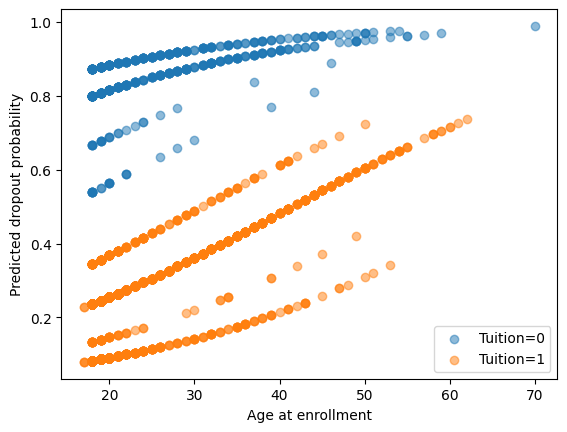

In [122]:
import matplotlib.pyplot as plt

# Predict probabilities
df['dropout_prob'] = model.predict_proba(X)[:, 1]

# Scatter plot
plt.figure()
for val in [0, 1]:
    subset = df[df['Tuition fees up to date'] == val]
    plt.scatter(subset['Age at enrollment'], subset['dropout_prob'], label=f'Tuition={val}', alpha=0.5)

plt.xlabel('Age at enrollment')
plt.ylabel('Predicted dropout probability')
plt.legend()
plt.show()

In [123]:
df.groupby('Tuition fees up to date')['dropout_prob'].mean()
effect = (
    df[df['Tuition fees up to date'] == 0]['dropout_prob'].mean()
    - df[df['Tuition fees up to date'] == 1]['dropout_prob'].mean()
)
print(effect)

0.6125849339840048


In [124]:
group_means = df.groupby('Tuition fees up to date')['dropout_prob'].mean()
print(group_means)

effect = group_means[0] - group_means[1]
print("Average reduction from being up-to-date:", effect)

Tuition fees up to date
0    0.860675
1    0.248090
Name: dropout_prob, dtype: float64
Average reduction from being up-to-date: 0.6125849339840048


The scatter plot shows predicted dropout probability as a function of age, separated by tuition status. Students who are not up to date on tuition consistently have much higher predicted dropout probabilities than those who are up to date. This difference is large across all ages which shows that tuition status is a strong predictor of dropout. Dropout probability increases with age for both groups. The gap between the two groups remains substantial across age range and appears slightly larger for older students. The effect appears slightly larger for older students (around 40-60+), where overall dropout risk is higher.  On average, being up to date on tuition reduces the predicted probability of dropout by approximately 0.61, indicating a very strong effect.

In [125]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)


Confusion Matrix:
 [[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


The logistic regression classifier achieves an accuracy of approximately 76.2%. The model performs well at identifying non-dropout students but is less effective at correctly identifying students who drop out, as indicated by the relatively high number of false negatives.

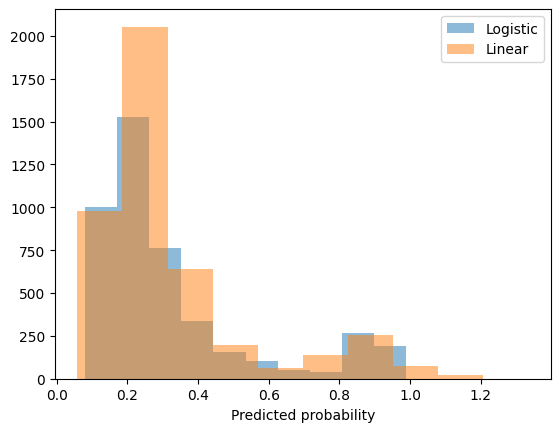

In [126]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df['lin_prob'] = lin_model.predict(X)

plt.figure()
plt.hist(df['dropout_prob'], alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], alpha=0.5, label='Linear')
plt.legend()
plt.xlabel('Predicted probability')
plt.show()

2.5 Part 1

The histogram shows that logistic regression produces predicted probabilities that are properly bounded between 0 and 1, while the linear model produces values outside this range, including values greater than 1. This makes the linear model unsuitable for probability prediction. Logistic regression provides more realistic and interpretable outputs, making it the better model for this classification task.

2.5 Part 2

Students who are not up to date on tuition, have outstanding debt, are not scholarship recipients, and are older are the most at risk of dropping out. Financial instability appears to be the strongest predictor. To support these students, institutions could provide financial aid programs, flexible payment plans, and academic support such as tutoring and advising. Early intervention systems could also help identify struggling students before they drop out.

In [127]:
from sklearn.linear_model import LogisticRegression

X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_multi, y_pred_multi))

probs = multi_model.predict_proba(X_multi)
print(probs[:5])

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The multinomial logistic regression model does not predict all classes when uusing hard classification, as one class is never selected as the predicted outcoem, which is evident from the 0 column in the confusion matrix. This suggests that the model struggles to distinguish that class from the others. However, the predicted probabilities from .predict_proba assign nonzero probabilities to all classes, indicating that the model does recognize the presence of each class but does not consider one of them as the most likely outcome. This highlights a limitation of relying solely on hard classifications.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [128]:
cdf = pd.read_csv("cirrhosis.csv")

# Keep relevant columns
cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
cdf = cdf[cols]

# Check missing values
print(cdf.isna().sum())


Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [129]:
cdf = cdf.dropna()

# Create the binary target variable 'survival'
cdf["survival"] = cdf["Status"].isin(["C", "CL"]).astype(int)

columns_to_dummies = [col for col in ["Edema", "Drug"] if col in cdf.columns]
if columns_to_dummies:
    cdf = pd.get_dummies(cdf, columns=columns_to_dummies, drop_first=True)

if 'Drug_Placebo' in cdf.columns:
    cdf["Drug_bin"] = 1 - cdf["Drug_Placebo"].astype(int)
else:

    cdf["Drug_bin"] = 1

The Drug variable contained 106 missing values and the Stage variable had 6 missing values. Since Drug is a key explanatory variable, rows with missing Drug values were removed from the dataset to avoid introducing bias or making unsupported assumptions about treatment assignment. This is also done with Stage.

In [130]:

from sklearn.linear_model import LogisticRegression

X = cdf.drop(columns=["Status", "survival"])
y = cdf["survival"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)


# Coefficients
coef_cdf = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coef_cdf)

        Feature  Coefficient
0     Bilirubin    -0.308810
1         Stage    -0.559417
2       Edema_S    -0.336307
3       Edema_Y    -1.368721
4  Drug_Placebo     0.162876
5      Drug_bin    -0.161520


- Drug (D-penicillamine): positive coef → slightly higher log-odds of survival vs placebo,
  but the drug does not clearly improve survival.
- Edema_S: negative coef → partial edema lowers survival probability vs no edema.
- Edema_Y: more negative coef → severe edema (unresponsive to diuretics) lowers survival
  probability even further. Edema worsens prognosis in both forms.
- Bilirubin: negative coef → higher bilirubin predicts LOWER survival rate.
  Elevated bilirubin reflects more severe liver dysfunction.

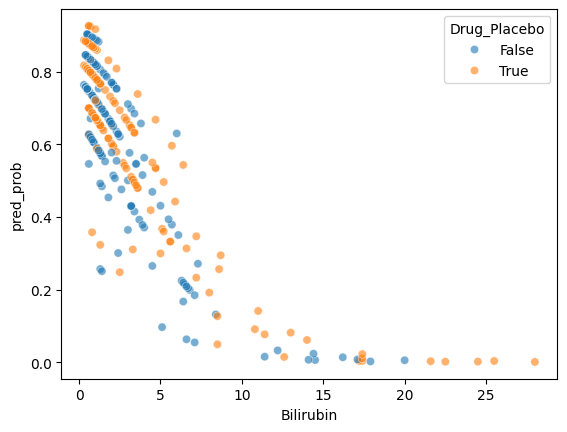

In [131]:
cdf["pred_prob"] = model.predict_proba(X)[:, 1]
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=cdf,
    x="Bilirubin",
    y="pred_prob",
    hue="Drug_Placebo",
    alpha=0.6
)
plt.show()

The scatter plot displays the predicted survival probability against Bilirubin levels, with different colors for patients receiving D-penicillamine and those receiving a placebo. It shows that higher bilirubin levels generally correspond to lower predicted survival probabilities for both groups. However, across all bilirubin levels, patients taking D-penicillamine tend to have slightly lower predicted survival probabilities compared to those on placebo. This suggests that the drug does not improve survival probability on average. The average increase in predicted survival probability from the drug is approximately -0.0190, indicating a slight decrease in survival probability for patients taking the drug compared to the placebo, as also observed from the scatter plot where the blue points (D-penicillamine) are generally below the red points (Placebo).



In [132]:
cdf.groupby("Drug_Placebo")["pred_prob"].mean()


,pred_prob
Drug_Placebo,
False,0.589633
True,0.609350


In [133]:
effect = (
    cdf[cdf["Drug_Placebo"] == True]["pred_prob"].mean()
    - cdf[cdf["Drug_Placebo"] == False]["pred_prob"].mean()
)
print(effect)

0.019717110424722795


This means that on average, the placebo group has a slgihtly higher predicted survival probability (1.97%) than those who received the drug. This reinforces the idea that the drug did not improve survival in this model since the placebo group showed a better outcome.

In [134]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print(acc)

[[ 66  59]
 [ 16 171]]
0.7596153846153846


The matrix shows the performance of the logistic regression model in classifying actual survival outcomes vs predicted survival outcomes:
- True negatives (66) - 66 patients will not survive
- False positives (59) - incorrectly predicts that 59 patients would survive
- False negatives (16) - incorrectly predicts that 16 patients will survive
- True positives - correctly predicted that 171 patients would survive

An accuracy of 76.0% means that the model correctly predicted the survival status for about 76.0% of the patients in the dataset, which is somewhat accurate.

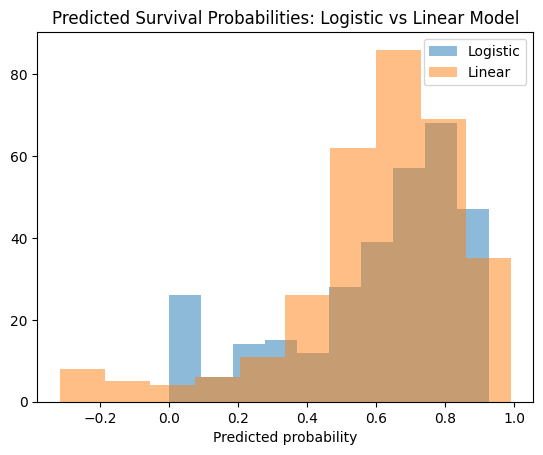

In [135]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
# Fit the linear model to the cirrhosis data (X, y)
lin_model.fit(X, y)

# Store linear model predictions in cdf
cdf['lin_prob'] = lin_model.predict(X)

plt.figure()
# Plot logistic regression probabilities from cdf['pred_prob']
plt.hist(cdf['pred_prob'], alpha=0.5, label='Logistic')
# Plot linear model probabilities from cdf['lin_prob']
plt.hist(cdf['lin_prob'], alpha=0.5, label='Linear')
plt.legend()
plt.xlabel('Predicted probability')
plt.title('Predicted Survival Probabilities: Logistic vs Linear Model')
plt.show()

Logistic regression produces valid probabilities between 0 and 1, while the linear model produces values outside this range. This makes logistic regression more appropriate for modeling survival probabilities.

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_stage = cdf.drop(columns=["Status", "survival"])
y_stage = cdf["Stage"]

multi_stage = LogisticRegression(max_iter=1000)
multi_stage.fit(X_stage, y_stage)

y_pred_stage = multi_stage.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_pred_stage)
print(cm_stage)

print(set(y_pred_stage))

probs_stage = multi_stage.predict_proba(X_stage)
print(probs_stage[:5])
print(multi_stage.classes_)

[[ 15   1   0   0]
 [  0  67   0   0]
 [  0   0 120   0]
 [  0   0   0 109]]
{np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)}
[[1.10017126e-09 2.22129765e-05 2.79973273e-02 9.71980459e-01]
 [6.24374219e-04 7.26660771e-02 8.74934553e-01 5.17749952e-02]
 [2.18896707e-08 5.74901908e-05 6.15584365e-02 9.38384051e-01]
 [1.96940718e-08 5.52483545e-05 6.00577582e-02 9.39886974e-01]
 [2.31322843e-04 6.65945505e-02 8.80684756e-01 5.24893704e-02]]
[1. 2. 3. 4.]


The confusion matrix shows that the model successfully predicts all disease stages (1, 2, 3, and 4), as indicated by the non-zero values along the diagonal for each stage. For example, 15 actual Stage 1 cases were correctly predicted as Stage 1, 67 actual Stage 2 cases were predicted as Stage 2, and so on. There was one misclassification where an actual Stage 1 case was predicted as Stage 2. The set(y_pred_stage) output confirms that the model's hard classifications include all four stages. The predict_proba output also shows non-zero probabilities assigned to all classes for each observation, indicating that the model considers the possibility of every stage, even when making a definitive classification.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

1.
The partial derivative with respect to $x_k$:
$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

A 1-unit increase in $x_k$ changes the prediction by exactly $b_k$. (Effect is constance and doesn't depend on x)

2.

Applying the hint and chain rule:
$$\frac{\partial \hat{p}}{\partial x_k} = \frac{e^L}{(1+e^L)^2} \cdot b_k = \hat{p}(1 - \hat{p}) \cdot b_k$$

It is different from linear because the derivative changes as x changes, not constant. The effect of $b_k$ is scaled by $\hat{p}(1-\hat{p})$, maximized at $\hat{p} = 0.5$. The max value of $\hat{p}(1-\hat{p}) = 0.25$

When $\hat{p} \approx 0.5$: $\frac{\partial \hat{p}}{\partial x_k} \approx \frac{b_k}{4}$, so $b_k \times 4$ is a good estimate of the effect near $\hat{p} = 0.5$

3.

From the algebraic transformation:
$$\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x$$

Differentiating with respect to $x_k$:
$$\frac{\partial}{\partial x_k}\left[\log\left(\frac{\hat{p}}{1-\hat{p}}\right)\right] = b_k$$

A 1-unit increase in $x_k$ raises the log odds by $b_k$, constant, like the linear case.
Equivalently: the odds multiply by $e^{b_k}$ per 1-unit increase in $x_k$.